In [2]:
import pandas as pd

df = pd.read_excel("Fashion_Retail_Sales.xlsx")

print("Before cleaning:", df.shape)

df = df.drop_duplicates()

print("After cleaning:", df.shape)
print("Duplicates remaining:", df.duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum())

Before cleaning: (9996, 4)
After cleaning: (9179, 4)
Duplicates remaining: 0

Missing values:
TransactionID      0
CustomerID         0
TransactionDate    0
Product            0
dtype: int64


In [3]:
df.to_excel("fashion_retail_sales_cleaned.xlsx", index=False)

In [4]:
product_sales = df["Product"].value_counts()

print(product_sales)

Product
T-Shirt     807
Jacket      807
Sneakers    796
Dress       778
Skirt       762
Shirt       759
Sweater     755
Shorts      754
Jeans       753
Scarf       751
Trouser     747
Boots       710
Name: count, dtype: int64


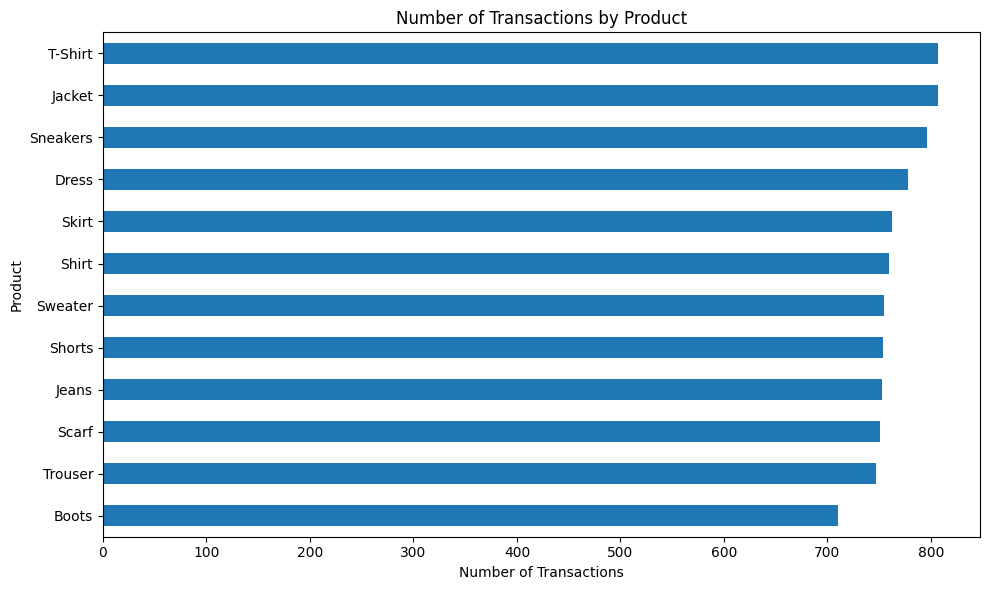

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

product_sales.sort_values(ascending=True).plot(kind="barh")

plt.title("Number of Transactions by Product")
plt.xlabel("Number of Transactions")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [6]:
# Convert TransactionDate to datetime
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

# Count transactions by month
monthly_sales = (
    df.groupby(df["TransactionDate"].dt.to_period("M"))
      .size()
)

print(monthly_sales)

TransactionDate
2021-03     23
2021-04    225
2021-05    223
2021-06    245
2021-07    263
2021-08    237
2021-09    249
2021-10    301
2021-11    293
2021-12    260
2022-01    233
2022-02    227
2022-03    233
2022-04    278
2022-05    249
2022-06    236
2022-07    230
2022-08    286
2022-09    269
2022-10    249
2022-11    267
2022-12    257
2023-01    259
2023-02    254
2023-03    255
2023-04    237
2023-05    221
2023-06    283
2023-07    304
2023-08    286
2023-09    283
2023-10    287
2023-11    255
2023-12    247
2024-01    264
2024-02    206
2024-03    205
Freq: M, dtype: int64


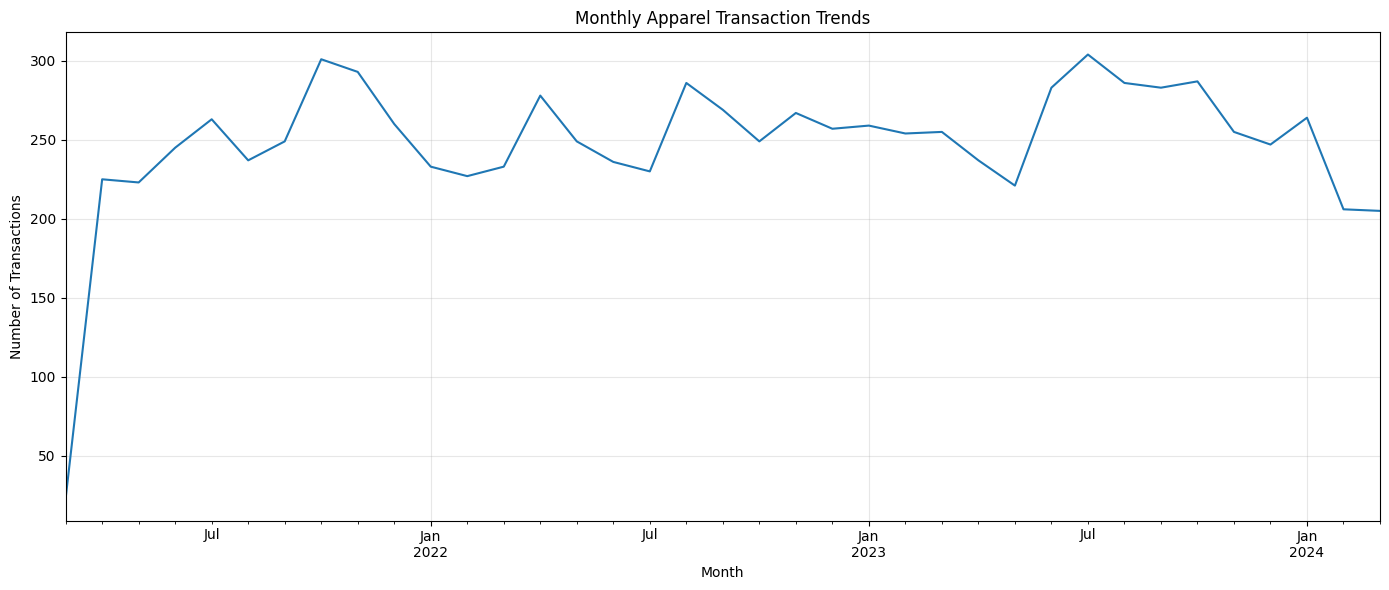

In [7]:
plt.figure(figsize=(14, 6))

monthly_sales.plot()

plt.title("Monthly Apparel Transaction Trends")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Extract month and year
df["Year"] = df["TransactionDate"].dt.year
df["Month"] = df["TransactionDate"].dt.month

# Calculate average transactions for each month across years
monthly_seasonality = (
    df.groupby(["Year", "Month"])
      .size()
      .groupby("Month")
      .mean()
)

print(monthly_seasonality)

Month
1     252.000000
2     229.000000
3     179.000000
4     246.666667
5     231.000000
6     254.666667
7     265.666667
8     269.666667
9     267.000000
10    279.000000
11    271.666667
12    254.666667
dtype: float64


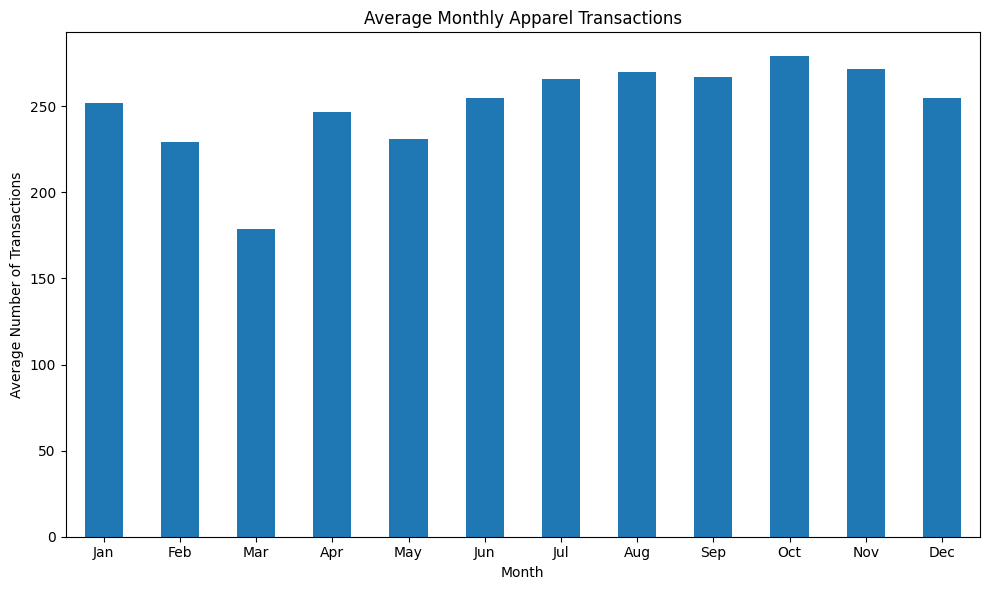

In [9]:
plt.figure(figsize=(10, 6))

monthly_seasonality.plot(kind="bar")

plt.title("Average Monthly Apparel Transactions")
plt.xlabel("Month")
plt.ylabel("Average Number of Transactions")
plt.xticks(
    range(12),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    rotation=0
)

plt.tight_layout()
plt.show()

In [10]:
# Calculate total transactions by year
yearly_sales = df.groupby("Year").size()

print("Transactions by year:")
print(yearly_sales)

Transactions by year:
Year
2021    2319
2022    3014
2023    3171
2024     675
dtype: int64


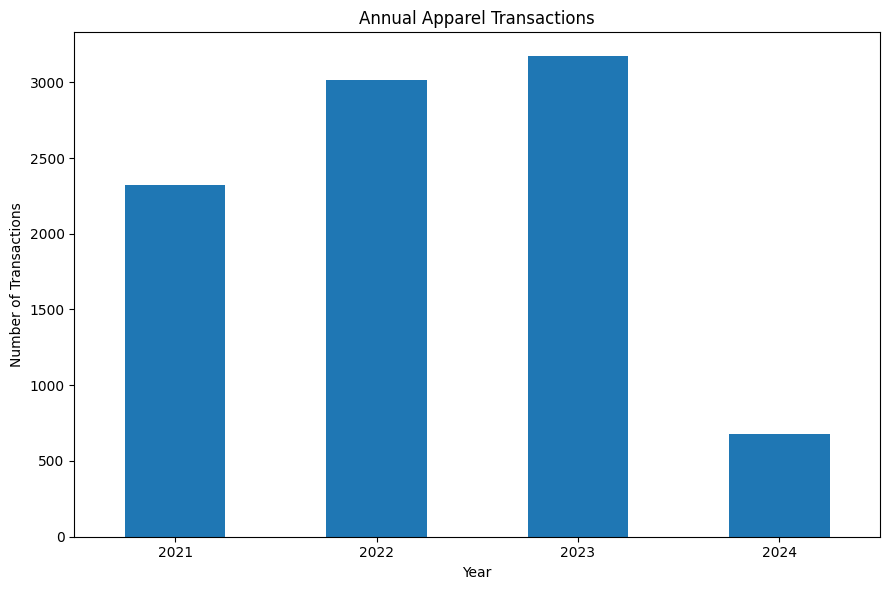

In [11]:
plt.figure(figsize=(9, 6))

yearly_sales.plot(kind="bar")

plt.title("Annual Apparel Transactions")
plt.xlabel("Year")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [12]:
# Count transactions by year and product
year_product_sales = pd.crosstab(df["Year"], df["Product"])

print(year_product_sales)

Product  Boots  Dress  Jacket  Jeans  Scarf  Shirt  Shorts  Skirt  Sneakers  \
Year                                                                          
2021       177    187     192    199    202    179     201    187       200   
2022       237    276     256    256    243    241     252    229       264   
2023       248    253     292    250    251    293     244    290       274   
2024        48     62      67     48     55     46      57     56        58   

Product  Sweater  T-Shirt  Trouser  
Year                                
2021         194      208      193  
2022         263      266      231  
2023         243      272      261  
2024          55       61       62  


<Figure size 1400x700 with 0 Axes>

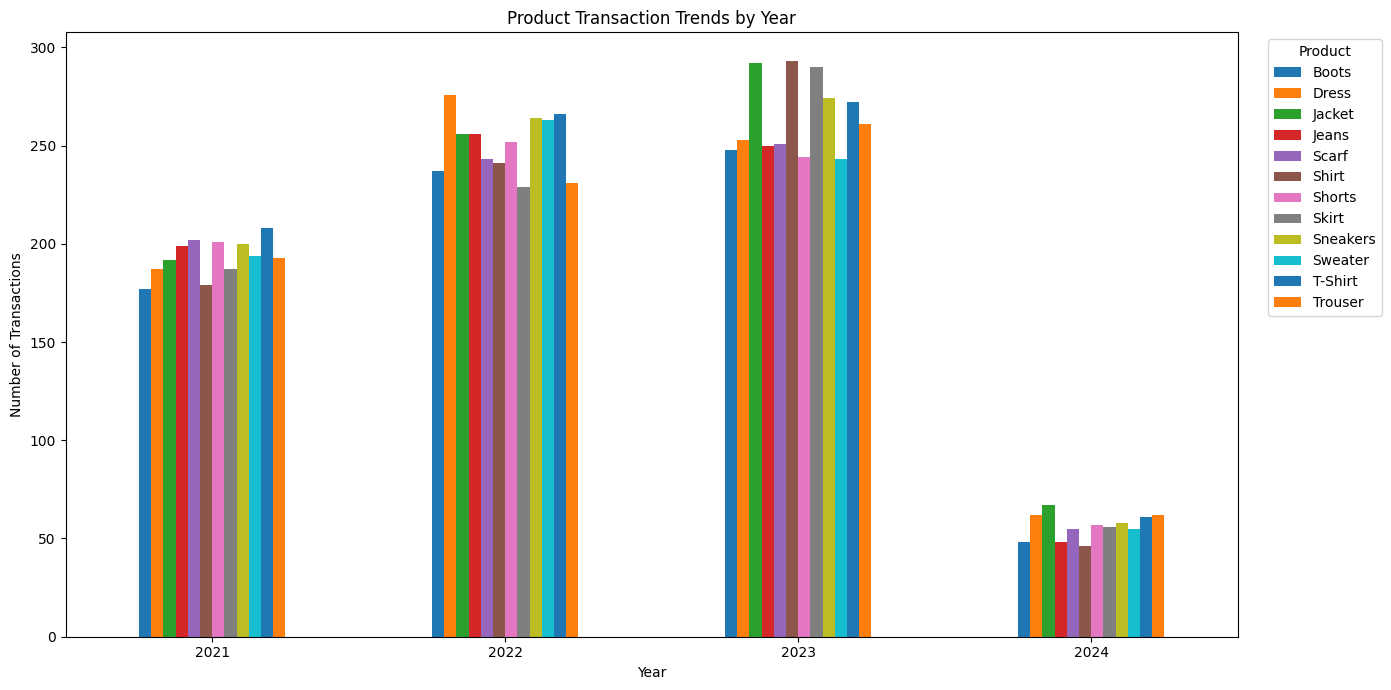

In [13]:
plt.figure(figsize=(14, 7))

year_product_sales.plot(kind="bar", figsize=(14, 7))

plt.title("Product Transaction Trends by Year")
plt.xlabel("Year")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.legend(title="Product", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [14]:
# Compare complete years: 2021 vs 2023
product_growth = year_product_sales.loc[[2021, 2023]].T

product_growth["Growth_%"] = (
    (product_growth[2023] - product_growth[2021])
    / product_growth[2021] * 100
)

product_growth = product_growth.sort_values("Growth_%", ascending=False)

print(product_growth)

Year      2021  2023   Growth_%
Product                        
Shirt      179   293  63.687151
Skirt      187   290  55.080214
Jacket     192   292  52.083333
Boots      177   248  40.112994
Sneakers   200   274  37.000000
Dress      187   253  35.294118
Trouser    193   261  35.233161
T-Shirt    208   272  30.769231
Jeans      199   250  25.628141
Sweater    194   243  25.257732
Scarf      202   251  24.257426
Shorts     201   244  21.393035


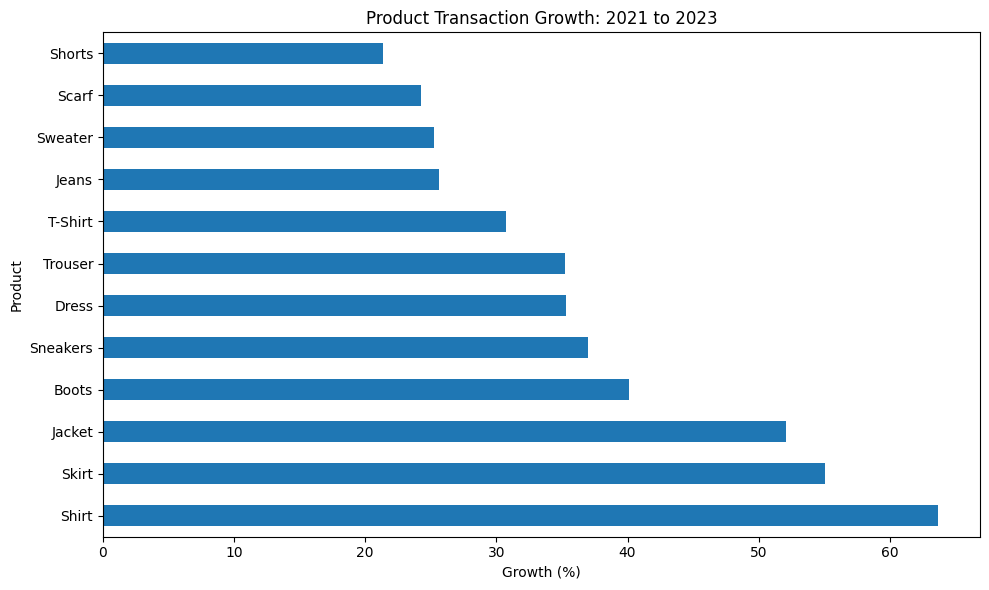

In [15]:
plt.figure(figsize=(10, 6))

product_growth["Growth_%"].plot(kind="barh")

plt.title("Product Transaction Growth: 2021 to 2023")
plt.xlabel("Growth (%)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [16]:
# Count transactions for each customer
customer_transactions = df["CustomerID"].value_counts()

print(customer_transactions.describe())

count    3913.000000
mean        2.345771
std         1.074568
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         8.000000
Name: count, dtype: float64


In [17]:
# Categorize customers by number of transactions
one_time = (customer_transactions == 1).sum()
repeat = (customer_transactions > 1).sum()

print("One-time customers:", one_time)
print("Repeat customers:", repeat)
print("Total unique customers:", len(customer_transactions))

One-time customers: 1024
Repeat customers: 2889
Total unique customers: 3913


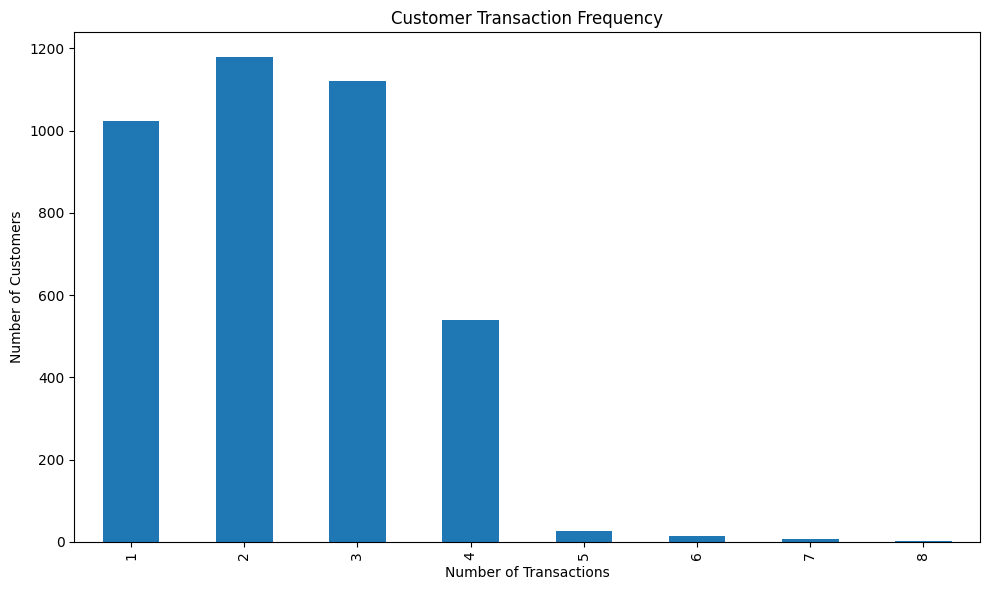

In [18]:
# Visualize customer transaction frequency
plt.figure(figsize=(10, 6))

customer_transactions.value_counts().sort_index().plot(kind="bar")

plt.title("Customer Transaction Frequency")
plt.xlabel("Number of Transactions")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [19]:
# Identify repeat customers
repeat_customers = customer_transactions[customer_transactions > 1].index

# Keep transactions from repeat customers
repeat_customer_data = df[df["CustomerID"].isin(repeat_customers)]

# Count products purchased by repeat customers
repeat_product_sales = repeat_customer_data["Product"].value_counts()

print(repeat_product_sales)

Product
T-Shirt     712
Sneakers    712
Jacket      706
Dress       689
Sweater     686
Jeans       680
Skirt       677
Shirt       675
Trouser     664
Shorts      664
Scarf       657
Boots       633
Name: count, dtype: int64


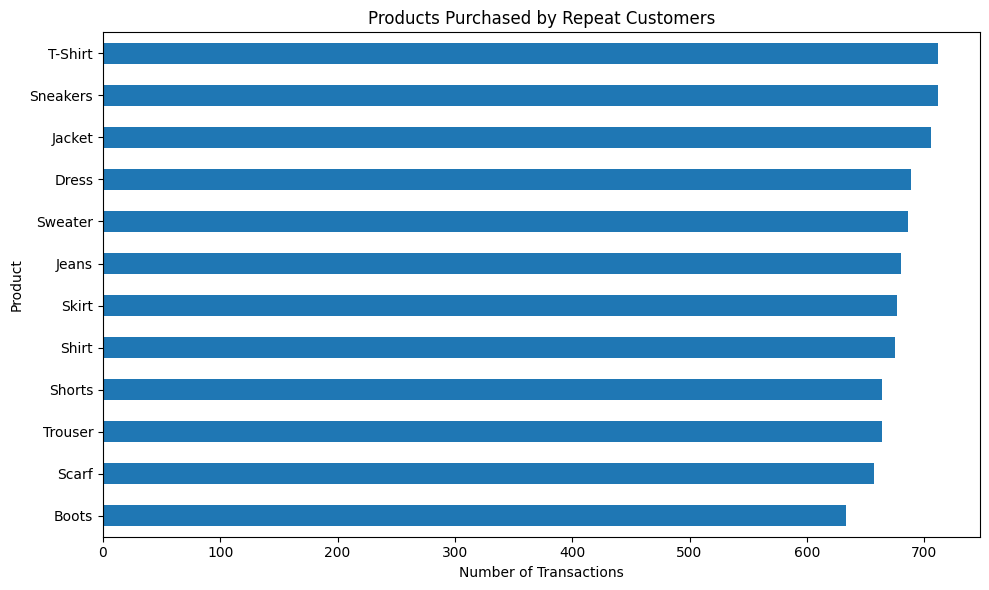

In [20]:
plt.figure(figsize=(10, 6))

repeat_product_sales.sort_values(ascending=True).plot(kind="barh")

plt.title("Products Purchased by Repeat Customers")
plt.xlabel("Number of Transactions")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [21]:
# Create monthly transaction demand by product

monthly_product_demand = (
    df.groupby([
        df["TransactionDate"].dt.to_period("M"),
        "Product"
    ])
    .size()
    .reset_index(name="Transactions")
)

monthly_product_demand["TransactionDate"] = (
    monthly_product_demand["TransactionDate"].dt.to_timestamp()
)

print(monthly_product_demand.head(20))
print("\nShape:", monthly_product_demand.shape)

   TransactionDate   Product  Transactions
0       2021-03-01     Boots             3
1       2021-03-01    Jacket             4
2       2021-03-01     Jeans             3
3       2021-03-01     Shirt             1
4       2021-03-01    Shorts             3
5       2021-03-01     Skirt             1
6       2021-03-01  Sneakers             1
7       2021-03-01   Sweater             1
8       2021-03-01   T-Shirt             3
9       2021-03-01   Trouser             3
10      2021-04-01     Boots            14
11      2021-04-01     Dress            15
12      2021-04-01    Jacket            17
13      2021-04-01     Jeans            20
14      2021-04-01     Scarf            19
15      2021-04-01     Shirt            18
16      2021-04-01    Shorts            19
17      2021-04-01     Skirt            16
18      2021-04-01  Sneakers            18
19      2021-04-01   Sweater            29

Shape: (442, 3)


In [22]:
# Create a complete month-by-product dataset

all_months = pd.date_range(
    start=monthly_product_demand["TransactionDate"].min(),
    end=monthly_product_demand["TransactionDate"].max(),
    freq="MS"
)

all_products = df["Product"].unique()

complete_index = pd.MultiIndex.from_product(
    [all_months, all_products],
    names=["TransactionDate", "Product"]
)

monthly_product_demand = (
    monthly_product_demand
    .set_index(["TransactionDate", "Product"])
    .reindex(complete_index, fill_value=0)
    .reset_index()
)

print(monthly_product_demand.head(20))
print("\nShape:", monthly_product_demand.shape)
print("\nZero-transaction rows:",
      (monthly_product_demand["Transactions"] == 0).sum())

   TransactionDate   Product  Transactions
0       2021-03-01   Trouser             3
1       2021-03-01    Shorts             3
2       2021-03-01   T-Shirt             3
3       2021-03-01   Sweater             1
4       2021-03-01     Shirt             1
5       2021-03-01  Sneakers             1
6       2021-03-01     Jeans             3
7       2021-03-01     Skirt             1
8       2021-03-01     Boots             3
9       2021-03-01     Dress             0
10      2021-03-01    Jacket             4
11      2021-03-01     Scarf             0
12      2021-04-01   Trouser            19
13      2021-04-01    Shorts            19
14      2021-04-01   T-Shirt            21
15      2021-04-01   Sweater            29
16      2021-04-01     Shirt            18
17      2021-04-01  Sneakers            18
18      2021-04-01     Jeans            20
19      2021-04-01     Skirt            16

Shape: (444, 3)

Zero-transaction rows: 2


In [23]:
# Select Jacket for forecasting

jacket_data = monthly_product_demand[
    monthly_product_demand["Product"] == "Jacket"
].copy()

jacket_data = jacket_data.sort_values("TransactionDate")

print(jacket_data)
print("\nShape:", jacket_data.shape)

    TransactionDate Product  Transactions
10       2021-03-01  Jacket             4
22       2021-04-01  Jacket            17
34       2021-05-01  Jacket            14
46       2021-06-01  Jacket            14
58       2021-07-01  Jacket            24
70       2021-08-01  Jacket            20
82       2021-09-01  Jacket            12
94       2021-10-01  Jacket            26
106      2021-11-01  Jacket            30
118      2021-12-01  Jacket            31
130      2022-01-01  Jacket            18
142      2022-02-01  Jacket            18
154      2022-03-01  Jacket            16
166      2022-04-01  Jacket            25
178      2022-05-01  Jacket            18
190      2022-06-01  Jacket            22
202      2022-07-01  Jacket            23
214      2022-08-01  Jacket            26
226      2022-09-01  Jacket            25
238      2022-10-01  Jacket            19
250      2022-11-01  Jacket            20
262      2022-12-01  Jacket            26
274      2023-01-01  Jacket       

In [24]:
# Time-based train-test split

train = jacket_data.iloc[:-8].copy()
test = jacket_data.iloc[-8:].copy()

print("Training period:")
print(train["TransactionDate"].min(), "to", train["TransactionDate"].max())

print("\nTesting period:")
print(test["TransactionDate"].min(), "to", test["TransactionDate"].max())

print("\nTraining rows:", len(train))
print("Testing rows:", len(test))

Training period:
2021-03-01 00:00:00 to 2023-07-01 00:00:00

Testing period:
2023-08-01 00:00:00 to 2024-03-01 00:00:00

Training rows: 29
Testing rows: 8


In [25]:
# Baseline forecast using the training average

baseline_value = train["Transactions"].mean()

test["Baseline_Prediction"] = baseline_value

print("Baseline prediction:", round(baseline_value, 2))

print("\nActual vs Baseline:")
print(
    test[
        ["TransactionDate", "Transactions", "Baseline_Prediction"]
    ]
)

Baseline prediction: 21.1

Actual vs Baseline:
    TransactionDate  Transactions  Baseline_Prediction
358      2023-08-01            22            21.103448
370      2023-09-01            18            21.103448
382      2023-10-01            30            21.103448
394      2023-11-01            32            21.103448
406      2023-12-01            26            21.103448
418      2024-01-01            23            21.103448
430      2024-02-01            19            21.103448
442      2024-03-01            25            21.103448


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

baseline_mae = mean_absolute_error(
    test["Transactions"],
    test["Baseline_Prediction"]
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        test["Transactions"],
        test["Baseline_Prediction"]
    )
)

print("Baseline MAE:", round(baseline_mae, 2))
print("Baseline RMSE:", round(baseline_rmse, 2))

Baseline MAE: 4.57
Baseline RMSE: 5.65


In [27]:
from sklearn.linear_model import LinearRegression

# Create time-based features
train = train.copy()
test = test.copy()

train["Month"] = train["TransactionDate"].dt.month
train["Time_Index"] = range(len(train))

test["Month"] = test["TransactionDate"].dt.month
test["Time_Index"] = range(len(train), len(train) + len(test))

# Features and target
features = ["Month", "Time_Index"]

X_train = train[features]
y_train = train["Transactions"]

X_test = test[features]
y_test = test["Transactions"]

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
test["ML_Prediction"] = model.predict(X_test)

print("Actual vs ML Prediction:")
print(
    test[
        ["TransactionDate", "Transactions", "ML_Prediction"]
    ]
)

Actual vs ML Prediction:
    TransactionDate  Transactions  ML_Prediction
358      2023-08-01            22      27.315514
370      2023-09-01            18      28.384255
382      2023-10-01            30      29.452996
394      2023-11-01            32      30.521736
406      2023-12-01            26      31.590477
418      2024-01-01            23      23.760708
430      2024-02-01            19      24.829448
442      2024-03-01            25      25.898189


In [28]:
# Evaluate the ML forecasting model

ml_mae = mean_absolute_error(
    y_test,
    test["ML_Prediction"]
)

ml_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test["ML_Prediction"]
    )
)

print("ML Model MAE:", round(ml_mae, 2))
print("ML Model RMSE:", round(ml_rmse, 2))

ML Model MAE: 3.85
ML Model RMSE: 5.06


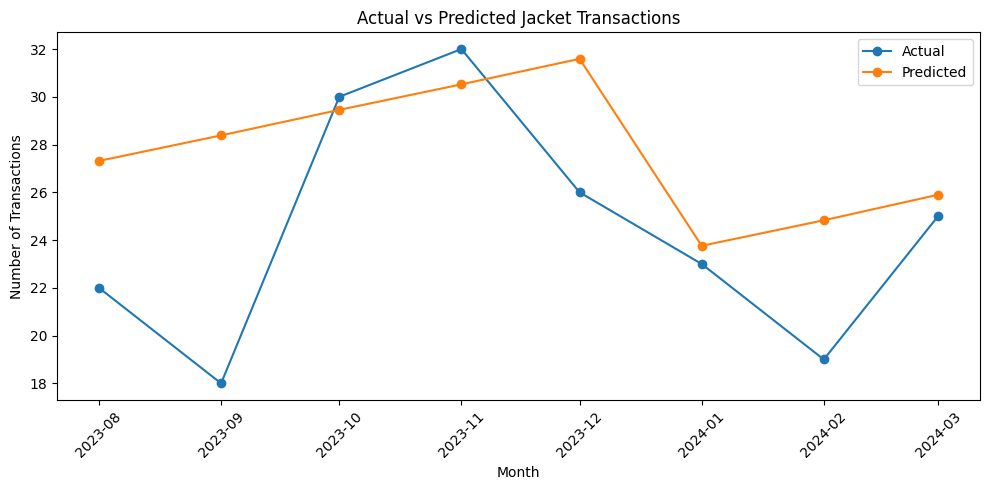

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    test["TransactionDate"],
    test["Transactions"],
    marker="o",
    label="Actual"
)

plt.plot(
    test["TransactionDate"],
    test["ML_Prediction"],
    marker="o",
    label="Predicted"
)

plt.title("Actual vs Predicted Jacket Transactions")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()